Tests of Fitting Algorithms
===========================

This is a notebook testing a couple of algorithms to fit the waveforms with Gaussians.  The usual fit takes a lot of time.
In the end the GPU based code is in `fitGaussian.ipynb`. 

## GAMPixPy output unit

Time: µs

In [1]:
import numpy as np
import pandas as pd
import h5py
from scipy import stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
edepsim_path = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch.h5'

In [3]:
# GAMPixPy outputs
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fT = simf['tiles']
    fP = simf['pixels']
    fM = simf['meta']
    print(fT.dtype)
    print(fP.dtype)
    print(fM.dtype)

    tempT = fT[()]
    tempP = fP[()]
    tempM = fM[()]

['meta', 'pixels', 'tiles']
[('event id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('pixel tpc', '<u4'), ('pixel x', '<f4'), ('pixel y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('primary energy', '<f4'), ('deposited charge', '<f4'), ('vertex x', '<f4'), ('vertex y', '<f4'), ('vertex z', '<f4'), ('theta', '<f4'), ('phi', '<f4'), ('primary length', '<f4')]


In [4]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]"
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]"
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]"
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]"
...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]"
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]"
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]"
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]"


In [5]:
dP = pd.DataFrame({
    name: tempP[name].tolist() if tempP[name].ndim > 1 else tempP[name]
    for name in tempP.dtype.names
})
dP

,event id,pixel tpc,pixel x,pixel y,trig z,trig t,waveform,attribution,label
0,0,0,-1067.25,-575.25,929.386963,5804.554199,"[40.82821273803711, 46.014671325683594, -53.52...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8158, 8157, -9999]"
1,0,0,-1066.75,-575.25,929.386963,5804.554199,"[-49.808319091796875, -35.9843864440918, -88.0...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8158, 8157, -9999]"
2,0,0,-1064.75,-534.75,1021.131958,6377.554199,"[-47.85734939575195, 19.129981994628906, 15.69...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1064.75,-534.25,1021.131958,6377.554199,"[-46.929325103759766, 8.915752410888672, 25.10...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
4,0,0,-1054.75,-573.25,-497.944031,-3109.945801,"[13.889131546020508, 399.57110595703125, 426.7...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.00000011...","[5816, -9999, -9999]"
...,...,...,...,...,...,...,...,...,...
3316069,999,0,-733.75,-351.25,386.780640,2415.666748,"[25.683349609375, -9.998589515686035, -29.8251...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, 8833146]"
3316070,999,0,-733.75,-350.75,386.780640,2415.666748,"[36.4698600769043, 96.0497055053711, 97.946617...","[[0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, 8833145]"
3316071,999,0,-733.25,-351.75,386.780640,2415.666748,"[35.43906784057617, -86.83092498779297, -94.36...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"
3316072,999,0,-733.25,-351.25,386.780640,2415.666748,"[107.39289855957031, -19.755084991455078, 0.61...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"


In [6]:
# edep-sim output for truth matching
with h5py.File(edepsim_path, 'r') as fg4:
    # Print all top-level groups/datasets
    print(list(fg4.keys()))
    fS = fg4['segments']
    # fT = fg4['trajectories']
    # fV = fg4['vertices']
    print(fS.dtype)
    # print(fT.dtype)
    # print(fV.dtype)
    
    tempS = fS[()]
    # tempT = fT[()]
    # tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE2dx', 'dE', 'dE2', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152], 'itemsize': 160}


In [7]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,t_end,dEdx,dE2dx,dE,dE2,t,y,x,z,n_photons
0,0,2166,2166,0,98.670486,2166,2166,0.0,98.706284,348.101868,...,0.0,0.063558,0.0,0.003178,0.0,0.0,-438.227661,348.086365,98.688385,0.0
1,0,2166,2166,1,98.668915,2168,2168,0.0,98.670486,348.104218,...,0.0,27.031174,0.0,0.089725,0.0,0.0,-438.236572,348.103027,98.669701,0.0
2,0,2166,2166,2,104.624596,2167,2167,0.0,104.624336,342.946564,...,0.0,50.987686,0.0,0.038659,0.0,0.0,-435.562378,342.946808,104.624466,0.0
3,0,2165,2165,3,283.540466,2165,2165,0.0,283.542053,349.946442,...,0.0,0.063542,0.0,0.003178,0.0,0.0,-332.630402,349.921570,283.541260,0.0
4,0,2165,2165,4,283.536835,2170,2170,0.0,283.540466,349.951935,...,0.0,20.367743,0.0,0.134589,0.0,0.0,-332.627686,349.949188,283.538635,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8835149,999,3,2090281,8835149,98.972160,3,7541269,0.0,98.977150,-118.376740,...,0.0,21.503775,0.0,0.124119,0.0,0.0,-469.179474,-118.378151,98.974655,0.0
8835150,999,2,2090280,8835150,112.352966,2,7541268,0.0,112.353348,-321.522552,...,0.0,26.071560,0.0,0.095099,0.0,0.0,-448.416565,-321.521240,112.353157,0.0
8835151,999,1,2090279,8835151,43.172062,1,7541267,0.0,43.163631,111.662086,...,0.0,16.500298,0.0,0.185769,0.0,0.0,-398.363098,111.664001,43.167847,0.0
8835152,999,1,2090279,8835152,43.172062,1,7541267,0.0,43.172062,111.662086,...,0.0,0.000000,0.0,0.000002,0.0,0.0,-398.366302,111.662086,43.172062,0.0


## Fit the waveforms with Gaussian

In [8]:
# time tick: 0.5µs
deltat = 0.5
t = np.arange(20, dtype = float) * deltat

In [9]:
noise = 50
threshold = 3*noise

### Fast version

In [10]:
# Convert list-column to a single contiguous 2D float array
wfT = np.vstack(dT["waveform"].to_numpy())  # shape: (n, 20)
dT["meanWF"] = wfT.mean(axis = 1)*deltat + dT['trig t']
dT["stdWF"] = wfT.std(axis = 1, ddof = 0)*deltat + dT['trig t']
dT["integWF"] = np.trapezoid(wfT, dx = deltat, axis = 1) 

In [11]:
wfP = np.vstack(dP['waveform'].to_numpy())
dP['meanWF'] = wfP.mean( axis = 1 )*deltat + dP['trig t']
dP['stdWF'] = wfP.std( axis = 1, ddof = 0)*deltat + dP['trig t']
dP['integWF'] = np.trapezoid(wfP, dx = deltat, axis = 1)

In [12]:
wfP_excess = np.clip(wfP - threshold, 0.0, None)
dP["integWF_3sd"] = np.trapezoid(wfP_excess, dx = deltat, axis = 1)

### Fit 2nd order polynominal

Take the log values of the waveforms and fit them with a 2nd order polynomial

In [13]:
wfTlog = np.log(np.clip(wfT, 1e-12, None))
coeffTlog = np.array([ np.polyfit( t, row, 2) for row in wfTlog ])
a = coeffTlog[:, 0]
b = coeffTlog[:, 1]
c = coeffTlog[:, 2]

In [14]:
np.sum(a>0)

np.int64(419248)

In [15]:
std = np.sqrt(-1./2*a)
mu = -b/(2*a)
A =  np.exp(c-b**2/(4*a))
I = np.sqrt(-np.pi/a)*A

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_11010/1624657133.py:1: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(-1./2*a)
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_11010/1624657133.py:3: RuntimeWarning: overflow encountered in exp
  A =  np.exp(c-b**2/(4*a))
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_11010/1624657133.py:4: RuntimeWarning: invalid value encountered in sqrt
  I = np.sqrt(-np.pi/a)*A
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_11010/1624657133.py:4: RuntimeWarning: overflow encountered in multiply
  I = np.sqrt(-np.pi/a)*A


In [16]:
maskI = np.isfinite(I)
I1 = I[maskI]
I1.min(), I1.max()

(np.float64(1.5439665197335879e-09), np.float64(1.3634725378963208e+308))

In [23]:
dT['mu'] = mu
dT['sigma'] = std
dT['A'] = A
dT['I'] = I

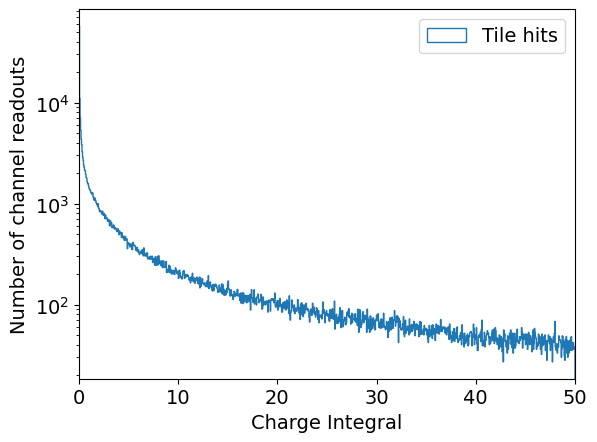

In [22]:
fig, ax = plt.subplots()


tBins = np.linspace(0, 50, 1000)
fonts = 14

ax.hist(I1, bins = tBins, histtype = 'step', label = 'Tile hits')
ax.set_yscale('log')
ax.set_xlim([0, 50])

ax.set_xlabel('Charge Integral', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

### Simple summation

In [24]:
dT['charge'] = dT['waveform'].apply(sum)
dP['charge'] = dP['waveform'].apply(sum)

In [25]:
diff = dT['I'] - dT['charge']/2
diff.min(), diff.max()

(-37169.0384254326, np.float64(inf))

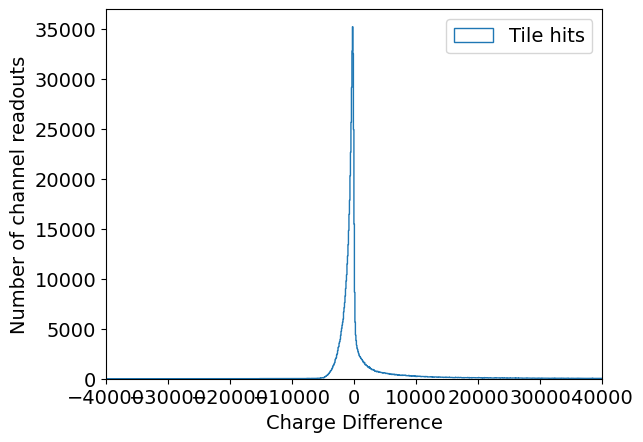

In [28]:
fig, ax = plt.subplots()


tBins = np.linspace(-40000, 40000, 1000)
fonts = 14

ax.hist(diff, bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-40000, 40000])

ax.set_xlabel('Charge Difference', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)